In [2]:
import os
import sys
sys.path.append(os.path.expanduser('~'))
import numpy as np 
import numba as nb
import time
import importlib
import json
import argparse
import h5py
from matplotlib import pyplot as plt
from datetime import datetime as dt

from albatros_analysis.src.correlations import baseband_data_classes as bdc
from albatros_analysis.src.utils import baseband_utils as butils
from albatros_analysis.src.utils import orbcomm_utils as outils

from scipy.optimize import minimize,check_grad,least_squares
from scipy.ndimage import median_filter
from scipy.ndimage import binary_opening, binary_closing, label
from skyfield.api import load, wgs84

import helper_finetiming as hf
import figures as fgs

sys.path.append(os.path.expanduser('~'))

BDC is using numpy
BDC is using numpy


In [3]:
#VIS STUFF
@nb.njit(parallel=True)
def apply_delay(arr, out, delay, freqs):
    # apply delay to an array of complex electric field or their correlation
    # does exp( j 2 pi nu tau) sign of tau is user dependent
    # freqs should correspond to the columns of the nspec x nchan array
    nspec = arr.shape[0]
    nchan = arr.shape[1]
    for i in nb.prange(nspec):
        for j in range(nchan):
            out[i, j] = arr[i, j] * np.exp(2j * np.pi * freqs[j] * delay[i])
    return out

@nb.njit(parallel=True)
def xcorr_avg(arr1,arr2,acclen):
    #helper function
    nblocks = arr1.shape[0]//acclen
    nchan = arr1.shape[1]
    out = np.zeros((nblocks,nchan),dtype=arr1.dtype)
    for i in nb.prange(nblocks):
        for j in range(acclen):
            for k in range(nchan):
                out[i,k] += arr1[i*acclen + j,k]*np.conj(arr2[i*acclen + j,k])
        out[i,:]/=acclen
    return out

def get_vis(data,satID,freqs, pstart,pend,antpos,ant_idxs,tle_path, T_SPECTRA,osamp,acclen):   
    n_blines = len(ant_idxs)*(len(ant_idxs)-1)//2
    multi_vis = np.zeros((n_blines, data.shape[2]//acclen, data.shape[3]), dtype='complex64', order='c')
    print("multi_vis shape", multi_vis.shape)

    bl_proc=0
    for i in range(len(ant_idxs)):
            for j in range(i+1, len(ant_idxs)):
                ai = ant_idxs[i]
                aj = ant_idxs[j]
                a1_coords=antpos[ai]
                a2_coords=antpos[aj]
                dly = outils.get_sat_delay(
                                    a1_coords,
                                    a2_coords,
                                    tle_path,
                                    pstart,
                                    int(pend - pstart)+2,
                                    satID,
                                    altaz=False
                                )
                delay = np.interp(
                    np.arange(0, data.shape[2]) * T_SPECTRA, np.arange(0, int(pend - pstart)+2), dly
                )
                spec1=data[ai,0,:,:]
                spec2=data[aj,0,:,:]
                spec2_phased = np.empty_like(spec2)
                # print("spec2", spec2_phased.shape)
                # print(spec2_phased.flags)
                spec2_phased = apply_delay(spec2, spec2_phased, -delay, freqs)
                Vxx = xcorr_avg(spec1,spec2_phased,acclen)
                spec1=data[ai,1,:,:]
                spec2=data[aj,1,:,:]
                spec2_phased = np.empty_like(spec2)
                spec2_phased = apply_delay(spec2, spec2_phased, -delay, freqs)
                Vyy = xcorr_avg(spec1,spec2_phased,acclen)
                multi_vis[bl_proc,:,:] = (Vxx+Vyy)/2
                bl_proc+=1
                print("done", ai,aj,".Processed",bl_proc, "baselines")
    return multi_vis

In [4]:
#FITTING STUFF
@nb.njit()
def func(tau_t, data, freq, weights):
    ''' 
    Get residuals for given tau at single time sample, for all blines

    Notes:
    - we set the reference antenna to zero delay: all other ants are with respect to it
    - therefore tau_t has length nant-1
    - residuals is 1D, and splits real and imag residuals up for fitting
    - convention is that timing difference is ai-aj
    '''
    # for one time sample
    nant=6
    nbl = nant*(nant-1)//2
    nfreq = len(freq)
    n_eval = nfreq * nbl
    residuals = np.zeros((2 * n_eval,), dtype="float64")
    for j in range(nfreq):
        blnum = 0
        two_pi_nu = 2 * np.pi * freq[j]
        for ai in range(nant):
            for aj in range(ai + 1, nant):
                rowidx = j * nbl + blnum
                if weights.ndim==2:
                    w = weights[blnum,j]
                else:
                    w = weights[blnum]
                if ai == 0:
                    pred = (
                        -two_pi_nu * tau_t[aj - 1]
                    )  # ant 0 is refant
                else:
                    pred = (
                        two_pi_nu * (tau_t[ai - 1] - tau_t[aj - 1])
                    )
                y = np.exp(1j * pred) - np.exp(1j*data[rowidx])
                residuals[rowidx] = w * np.real(y)
                residuals[rowidx + n_eval] = w * np.imag(y)
                blnum += 1
    return residuals

@nb.njit()
def jac(tau_t, data, freq, weights):
    '''
    Get the Jacobian for given tau at single time sample, for all blines

    Notes:
    - Antenna 0 is the reference so its delay is zero
    - therefore tau_t has length nant-1
    '''
    nant=6
    nbl = nant*(nant-1)//2
    nfreq = len(freq)
    n_eval = nfreq * nbl
    J = np.zeros((2 * n_eval, nant-1), dtype="float64")
    for j in range(nfreq):
        blnum = 0
        two_pi_nu = 2 * np.pi * freq[j]
        for ai in range(nant):
            for aj in range(ai + 1, nant):
                rowidx = j * nbl + blnum
                if weights.ndim==2:
                    w = weights[blnum,j]
                else:
                    w = weights[blnum]
                if ai == 0:
                    pred = (
                        -two_pi_nu * tau_t[aj - 1]
                    )  # ant 0 is refant
                    ym = np.exp(1j * pred)
                    dtheta = 1j * ym * w
                    re = two_pi_nu * np.real(dtheta)
                    im = two_pi_nu * np.imag(dtheta)
                    J[rowidx, aj - 1] = -re
                    J[rowidx + n_eval, aj - 1] = -im
                else:
                    pred = (
                        two_pi_nu * (tau_t[ai - 1] - tau_t[aj - 1])
                    )
                    ym = np.exp(1j * pred)
                    dtheta = 1j * ym * w
                    re = two_pi_nu * np.real(dtheta)
                    im = two_pi_nu * np.imag(dtheta)
                    J[rowidx, ai - 1] = re
                    J[rowidx, aj - 1] = -re
                    J[rowidx + n_eval, ai - 1] = im
                    J[rowidx + n_eval, aj - 1] = -im
                blnum += 1
    return J

In [5]:
#DATA MANIPULATION

def get_mask(vis, tol=1.5): 
    angle = np.angle(vis[:,:,:])
    _, ntimes, nchans = vis.shape

    fig, ax = plt.subplots(2,2,sharex=True)
    fig.set_size_inches(10, 10)
    img=ax[0,0].imshow(angle[0,:,:],aspect='auto',interpolation='none',cmap='RdBu')
    ax[0,0].set_title(f'Angles for Bline Index 0')

    x = np.arange(ntimes)
    residuals = np.zeros((n_blines, ntimes, nchans),dtype='float64')
    blnum=0
    for i in range(len(ant_idxs)):
        for j in range(i+1, len(ant_idxs)):
            ai = ant_idxs[i]
            aj = ant_idxs[j]
            for k in range(angle.shape[2]):
                m, c = np.polyfit(x, angle[blnum,:,k], 1)
                residuals[blnum, :, k] = angle[blnum,:,k] - (m*x + c)
            blnum+=1

    mad = np.median(np.abs(residuals[:,:,:]), axis=0)
    img = ax[0,1].imshow(mad, aspect='auto',interpolation='none')
    ax[0,1].set_title('MAD across all blines')
    fig.colorbar(img, ax=ax[0,1])

    mask = mad > tol
    img = ax[1,0].imshow(mask, aspect='auto',interpolation='none')
    ax[1,0].set_title('Raw Mask all Blines')

    mask = binary_closing(mask, structure=np.ones((7,1)))
    mask_pulse = np.zeros_like(mask, dtype=bool)
    n_time, n_chan = mask.shape

    for ch in range(n_chan):
        labeled, n_features = label(mask[:, ch])
        for i in range(1, n_features + 1):
            # indices of this block
            block = (labeled == i)
            if block.sum() >= 5:
                mask_pulse[:, ch][block] = True

    img = ax[1,1].imshow(mask_pulse, aspect='auto',interpolation='none')
    ax[1,1].set_title('Filtered Mask all blines')
    return mask_pulse


def get_thermal_noise(vis, ant_idxs, mask=None):

    fig,ax = plt.subplots(5,3, constrained_layout=True)
    fig.set_size_inches(10,15)
    ax=np.ravel(ax)
    plt.suptitle(f"stokes I (phase), int. time {T_SPECTRA*acclen:4.2f}s")
    nblines, ntimes, nchans = vis.shape

    thermal_noise = np.zeros((nblines, ntimes),dtype='float64')
    vis_noise = np.zeros((nblines, ntimes),dtype='float64')
    x_all  = np.arange(nchans)
    angle = np.angle(vis)
    blnum = 0
    for i in range(len(ant_idxs)):
        for j in range(i+1, len(ant_idxs)):
            ai = ant_idxs[i]
            aj = ant_idxs[j]
            ax[blnum].set_title(f"{antmap[ai]}-{antmap[aj]} (id {blnum})")
            a = angle[blnum, :, :].copy()  # (ntimes, nchan)

            if mask is None:
                a2=np.unwrap(a,axis=1)
                for k in range(a2.shape[0]):
                    m, c = np.polyfit(x_all, a2[k,:], 1)
                    residual = a2[k,:] - (m*x_all + c)
                    # sigma_phi = np.sqrt(np.mean(residual**2))
                    sigma_phi = np.std(np.angle(np.exp(1j*residual)))
                    thermal_noise[blnum,k] = sigma_phi
                    vis_noise[blnum,k] = np.std(np.cos(residual))
                img=ax[blnum].imshow(np.angle(vis[blnum,:,:]),aspect='auto',interpolation='none',cmap='RdBu')
                cbar=plt.colorbar(img,ax=ax[blnum])
            else:
                #iterate over all time chunks
                for k in range(ntimes):
                    good_idx = ~mask[k, :]
                    if good_idx.sum() < 2:
                        #print(f"Too few points to fit for time {k}")
                        thermal_noise[blnum, k] = 1
                        continue

                    elif good_idx.sum() < 10:
                        #print(f'Very few channels time {k}')
                        thermal_noise[blnum, k] = 1
                        continue

                    # unwrap and fit linear phase ramp (only for 'good' data)
                    phase_good = np.unwrap(a[k, good_idx])
                    x = np.arange(a.shape[1])[good_idx]
                    y = phase_good
                    m, c = np.polyfit(x, y, 1)

                    # get noise on ramp (only for 'good' data)
                    residual = y - (m * x + c)
                    sigma_phi = np.std(np.angle(np.exp(1j * residual)))  # circular std
                    vis_noise_val = np.std(np.cos(residual))

                    thermal_noise[blnum, k] = sigma_phi
                    vis_noise[blnum, k] = vis_noise_val

                # plot masked arrays
                a_masked = np.ma.masked_where(mask, np.angle(vis[blnum, :, :]))
                img = ax[blnum].imshow(a_masked, aspect='auto', interpolation='none', cmap='RdBu')
                plt.colorbar(img, ax=ax[blnum])
            blnum+=1
    return thermal_noise

def find_lowest_noise(noise, window_size=120):
    nblines, ntimes = noise.shape
    min_noise = float('inf')
    best_start_idx = -1

    for t in range(ntimes - window_size + 1):
        # Slice over time, keep all baselines
        window = noise[:, t:t + window_size]
        
        # Collapse both dimensions → single statistic
        window_noise = np.median(window)  # or np.mean(window)
        
        if window_noise < min_noise:
            min_noise = window_noise
            best_start_idx = t

    return best_start_idx, best_start_idx+window_size


# START OF CODE

In [6]:
path_config = "/home/thomasb/albatros_analysis/scripts/orbcomm/config/config_batch2.json"

with open(path_config, "r") as f:
    config = json.load(f)
antpos=[]
for i, (ant, details) in enumerate(config["antennas"].items()):
    antpos.append(details["coordinates"])
print(antpos)

batch_start_ts = config["correlation"]["start_timestamp"]
batch_end_ts = config["correlation"]["end_timestamp"]
osamp = config['correlation']['osamp']
acclen = config['correlation']['new_acclen']

T_SPECTRA = 4096/250e6 * osamp
print(T_SPECTRA)

[[79.41717895, -90.76721818, 188.095], [79.41721848, -90.75872502, 183.51076468], [79.38845797, -91.01936185, 19.777], [79.4183154, -90.667425, 59.364], [79.3979952, -90.799868, 42.692], [79.41148497, -90.69528512, 32.593], [79.44377162, -90.71824306, 416.829]]
0.001048576


In [7]:
path_batch = f'/scratch/thomasb/batch_{batch_start_ts}'

fname_pulses = "data/pulses2.json"
path_pulses = os.path.join(path_batch, fname_pulses)

fname_cutter_discrep = "data/cutting_discrep.json"
path_cutter_discrep = os.path.join(path_batch, fname_cutter_discrep)

fname_map = 'timing_discrepancies/times_all_incoherent.json'
path_map = os.path.join(path_batch, fname_map)

In [8]:
with open(path_pulses, "r") as f_pulses:
        pulse_list = json.load(f_pulses)

with open(path_cutter_discrep, "r") as f_cutter:
        dict_cutter_discrep = json.load(f_cutter)

with open(path_map, "r") as f_map:
        map_dict = json.load(f_map)

In [9]:
taus_fitted_all = {}
overflow = False

ant_idxs = [0, 2, 3, 4, 5, 6]
antmap = {0:"MARS1", 1:"MARS2",2:"MARS4",3:"MARS5",4:"MARS6",5:"MARS7",6:"MARS8"}
nant_used = len(ant_idxs)
n_blines = len(ant_idxs)*(len(ant_idxs)-1)//2

In [93]:
idx_pulse = 3

#extract from pulses json
pulse = pulse_list[idx_pulse]
print(pulse)

pulse_start_ts = pulse['t_start']
pulse_end_ts = pulse['t_end']
satID = pulse['sat']
chan_det = pulse['channel']
print('detection channel', chan_det)

assert satID in {59051, 57166, 28654,25338,33591}
if satID in {59051, 57166}:
    masking = False
if satID in {28654,25338,33591}:
    masking=True

print('masking:', masking)

ant_idxs = [0, 2, 3, 4, 5, 6]
ant_nums = [1, 2, 4, 5, 6, 7, 8]

if chan_det%2 == 0:
    chans_old = np.arange(chan_det-2, chan_det+2) + 1834
else:
    chans_old = np.arange(chan_det-1, chan_det+3) + 1834

print(chans_old)

{'antenna': 'Antenna 2', 'sat': 25338, 'channel': 7, 't_start': 1753206540, 't_end': 1753206785, 'len': 245}
detection channel 7
masking: True
[1840 1841 1842 1843]


In [94]:
fname_data = f"data_raw_osamp=64_start={pulse_start_ts}_end={pulse_end_ts}_chans={chans_old[0]}:{chans_old[-1]}.npy"

#extract from discrep cutter (to get channels)
cut_discrep = dict_cutter_discrep[fname_data]

chan_new_start, chan_new_end  = cut_discrep["new_chans"]
chans_new = np.arange(chan_new_start, chan_new_end)
nchans = len(chans_new)
print(nchans)
print(chans_new)

freqs = (chans_new/64 + chans_old[0])*250e6/4096
freqs = 250e6-freqs

data1 = np.load(os.path.join(path_batch, 'data', fname_data))
data1 = data1[:, :, :, chans_new]
nant = data1.shape[0]
print(data1.shape)
print(nant)

20
[70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89]
(7, 2, 233472, 20)
7


In [95]:
#extract from mapping json
map = map_dict[fname_data]
overflow = False
#pulse_start_spec = map["start_spectrum"] 

pulse_start_spec = map["start_spectrum"]
# if overflow==True:
#     pulse_start_spec+=2**32
print('starting specnum', pulse_start_spec)

#batch 2
spec_per_UTC = 1.638400946109685e-05
UTC_offset = 1753200128.469018

pstart1 = spec_per_UTC*pulse_start_spec + UTC_offset
print(pstart1)

tle_path = outils.get_tle_file(pstart1, "/project/rrg-sievers/mohanagr/OCOMM_TLES")

starting specnum 391315403
1753206539.784283


In [96]:
vis1 = get_vis(data1,satID,freqs,pstart1,pulse_end_ts,antpos,ant_idxs,tle_path,T_SPECTRA,osamp,acclen)

multi_vis shape (15, 228, 20)
catalog #25338 epoch 2025-07-22 19:02:38 UTC
one delay prediction: 0.13725805282592773
done 0 2 .Processed 1 baselines
catalog #25338 epoch 2025-07-22 19:02:38 UTC
one delay prediction: 0.13172626495361328
done 0 3 .Processed 2 baselines
catalog #25338 epoch 2025-07-22 19:02:38 UTC
one delay prediction: 0.13302326202392578
done 0 4 .Processed 3 baselines
catalog #25338 epoch 2025-07-22 19:02:38 UTC
one delay prediction: 0.13171005249023438
done 0 5 .Processed 4 baselines
catalog #25338 epoch 2025-07-22 19:02:38 UTC
one delay prediction: 0.13204574584960938
done 0 6 .Processed 5 baselines
catalog #25338 epoch 2025-07-22 19:02:38 UTC
one delay prediction: 0.13267993927001953
done 2 3 .Processed 6 baselines
catalog #25338 epoch 2025-07-22 19:02:38 UTC
one delay prediction: 0.1320488452911377
done 2 4 .Processed 7 baselines
catalog #25338 epoch 2025-07-22 19:02:38 UTC
one delay prediction: 0.12961578369140625
done 2 5 .Processed 8 baselines
catalog #25338 epoc

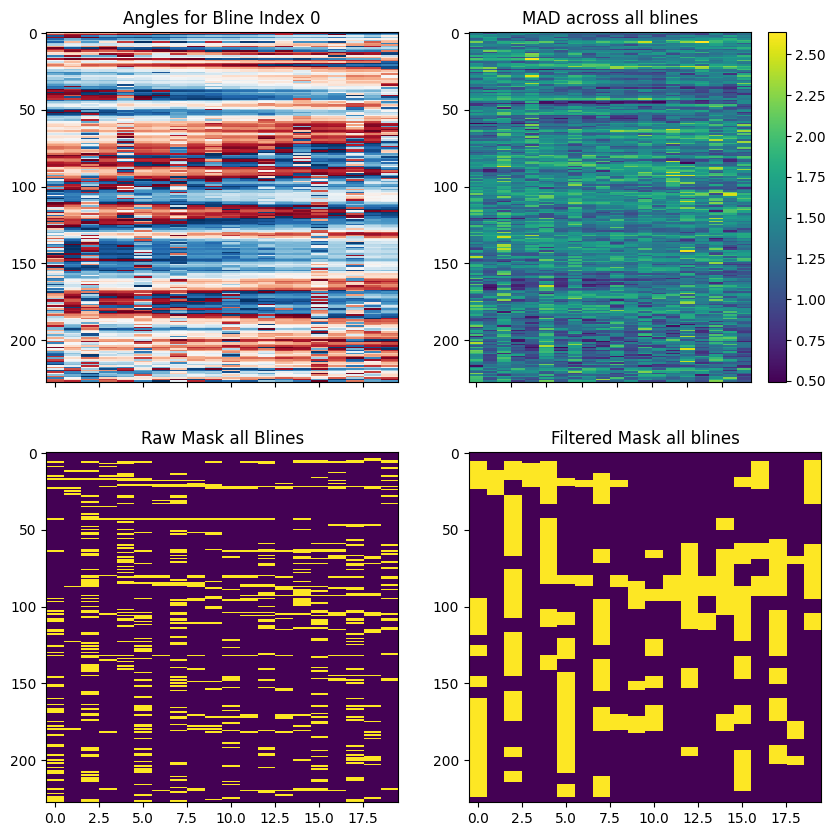

In [102]:
#make adaptive. while loop maybe? needs a minimum number of real points.
if masking:
    mask1 = get_mask(vis1, tol=1.8)
else:
    mask1 = None

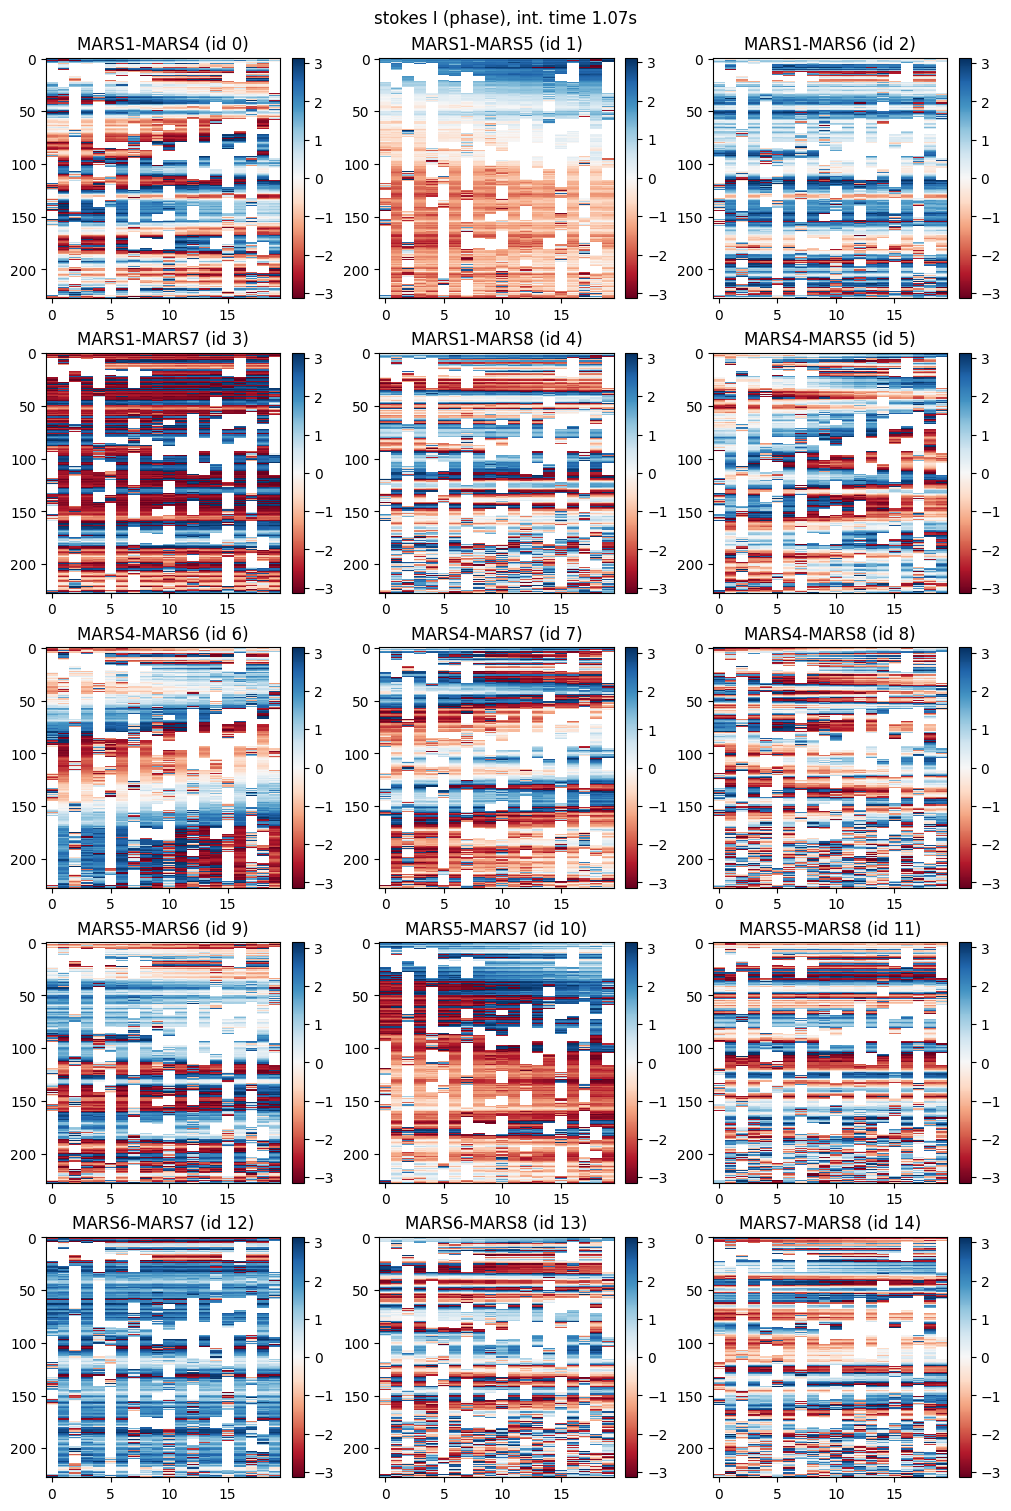

In [103]:
thermal_noise1 = get_thermal_noise(vis1,ant_idxs,mask=mask1)

(15, 228)


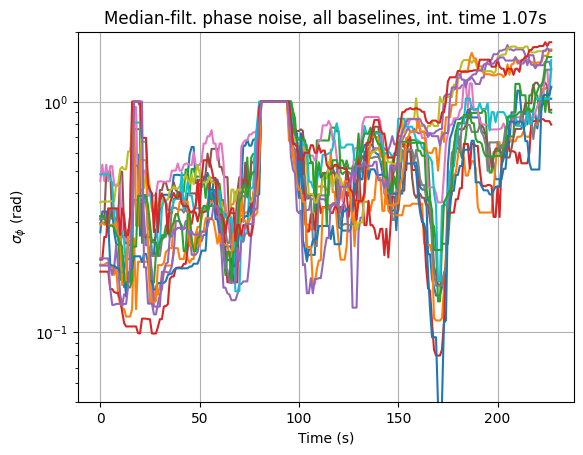

In [104]:
print(thermal_noise1.shape)
for bl in range(n_blines):
    plt.semilogy(median_filter(thermal_noise1[bl,:],10),label=f'bl id {bl}')
plt.title(f"Median-filt. phase noise, all baselines, int. time {T_SPECTRA*acclen:4.2f}s")
plt.ylabel("$\sigma_\phi$ (rad)")
plt.xlabel("Time (s)")
plt.ylim(0.05,2)
plt.grid(True)

In [105]:
start_cut, end_cut = find_lowest_noise(thermal_noise1)


#start_cut, end_cut = 10, 130

print(start_cut, end_cut)
start_spectra, end_spectra = start_cut*acclen, end_cut*acclen

0 120


In [106]:
pulse_start_spec_cut = pulse_start_spec+start_spectra*64
pstart2 = spec_per_UTC*pulse_start_spec_cut + UTC_offset
print(pstart2)

data2 = data1[:,:,start_spectra:end_spectra,:]
print(data2.shape)

1753206539.784283
(7, 2, 122880, 20)


In [107]:
vis2=get_vis(data2,satID,freqs,pstart2,pulse_end_ts,antpos,ant_idxs,tle_path,T_SPECTRA,osamp,acclen)
nblines, ntimes, nchans = vis2.shape
print(vis2.shape)

multi_vis shape (15, 120, 20)
catalog #25338 epoch 2025-07-22 19:02:38 UTC
one delay prediction: 0.13154244422912598
done 0 2 .Processed 1 baselines
catalog #25338 epoch 2025-07-22 19:02:38 UTC
one delay prediction: 0.12801480293273926
done 0 3 .Processed 2 baselines
catalog #25338 epoch 2025-07-22 19:02:38 UTC
one delay prediction: 0.128218412399292
done 0 4 .Processed 3 baselines
catalog #25338 epoch 2025-07-22 19:02:38 UTC
one delay prediction: 0.13344788551330566
done 0 5 .Processed 4 baselines
catalog #25338 epoch 2025-07-22 19:02:38 UTC
one delay prediction: 0.1333446502685547
done 0 6 .Processed 5 baselines
catalog #25338 epoch 2025-07-22 19:02:38 UTC
one delay prediction: 0.13254261016845703
done 2 3 .Processed 6 baselines
catalog #25338 epoch 2025-07-22 19:02:38 UTC
one delay prediction: 0.1633749008178711
done 2 4 .Processed 7 baselines
catalog #25338 epoch 2025-07-22 19:02:38 UTC
one delay prediction: 0.13157057762145996
done 2 5 .Processed 8 baselines
catalog #25338 epoch 2

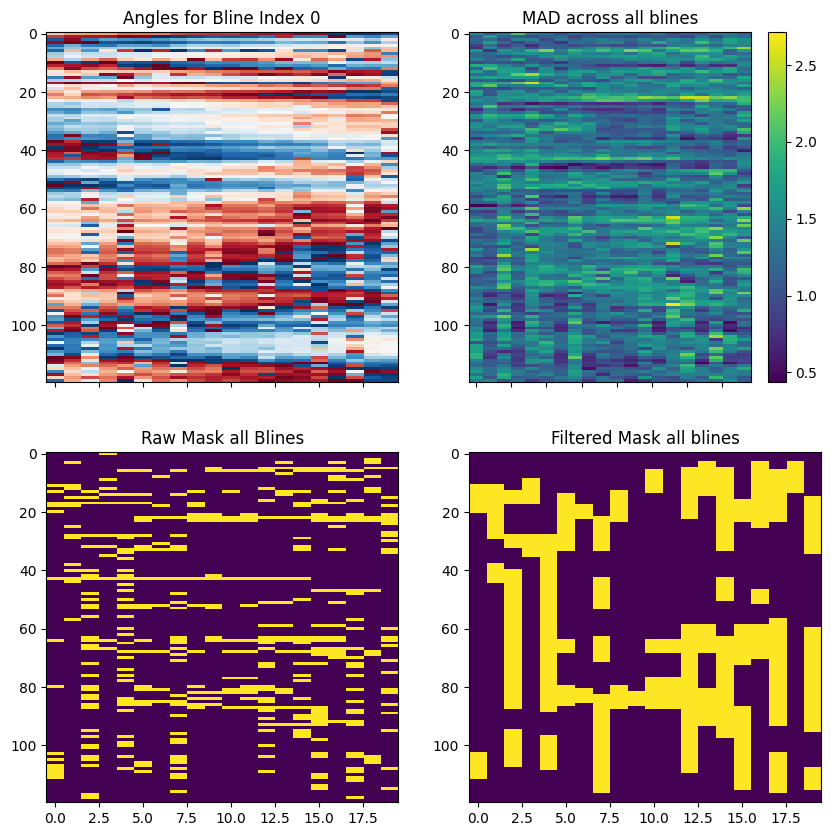

In [113]:
if masking:
    mask2 = get_mask(vis2, tol=1.7)
else:
    mask2 = None

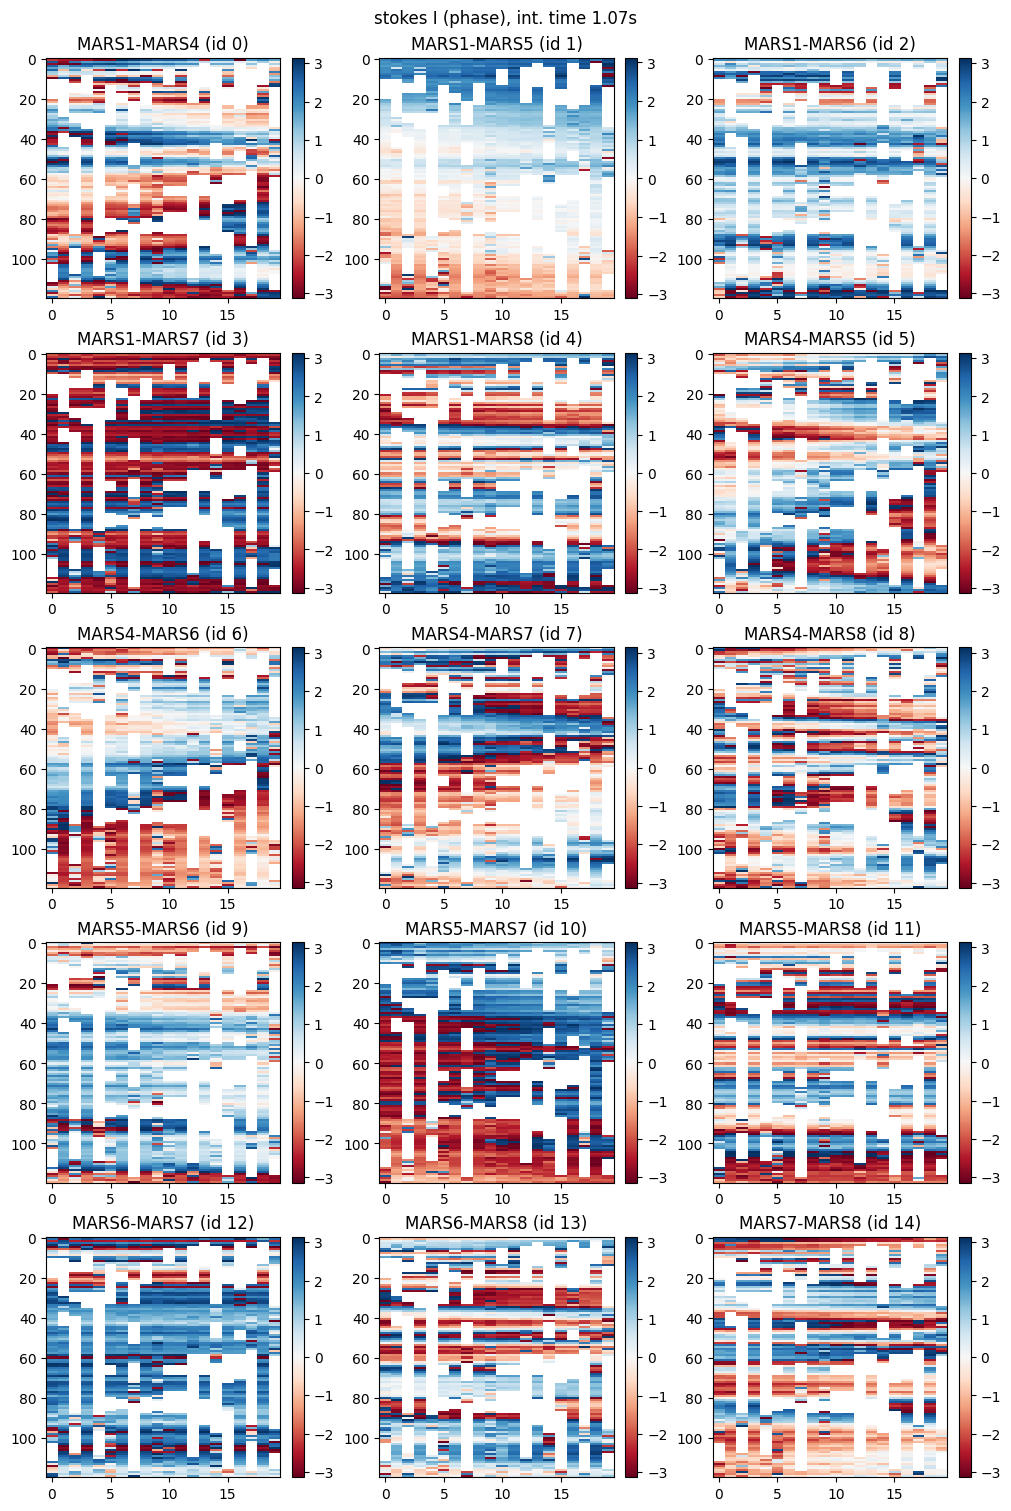

In [114]:
thermal_noise2 = get_thermal_noise(vis2, ant_idxs, mask=mask2)

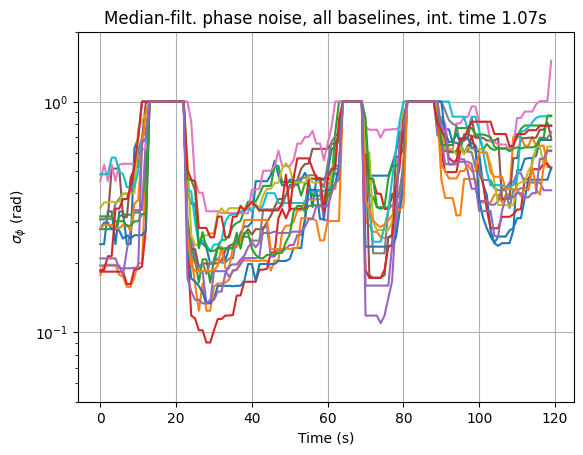

In [115]:
for bl in range(n_blines):
    plt.semilogy(median_filter(thermal_noise2[bl,:],10),label=f'bl id {bl}')
plt.title(f"Median-filt. phase noise, all baselines, int. time {T_SPECTRA*acclen:4.2f}s")
plt.ylabel("$\sigma_\phi$ (rad)")
plt.xlabel("Time (s)")
plt.ylim(0.05,2)
plt.grid(True)

noise var shape (15, 120)
data_matrix shape (120, 20, 15)
weight_matrix shape (120, 20, 15)
noise matrix shape (120, 15)
ntimes 120
nchans 20
nblines 15
nant used: 6


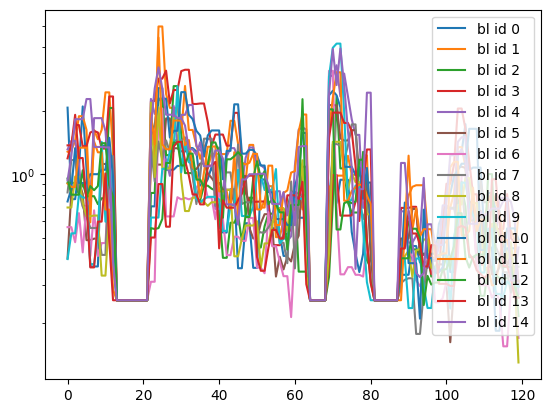

In [116]:
noise_var = median_filter(thermal_noise2[:,:],3,axes=1)**2   #why a median filter of just 3??
print('noise var shape', noise_var.shape)

weights = np.sqrt(np.size(noise_var)/noise_var/np.sum(1/noise_var))
angle = np.angle(vis2)

if masking:
    weights = np.tile(weights[:, :, None], (1, 1, nchans))
    weights = np.where(mask2[None, :, :], 0, weights)
    weight_matrix = weights.transpose(1,2,0).copy() #do same for weights so it follows
    phase_unwrapped = angle

    for bl in range(n_blines):
        #max is fine since weights either zero or depend on full channel thermal noise
        plt.semilogy(np.max(weights[bl,:, :], axis=1),label=f'bl id {bl}')
    plt.legend()

else:
    phase_unwrapped = angle
    weight_matrix = weights.T.copy()
    for bl in range(n_blines):
        plt.semilogy(weights[bl,:],label=f'bl id {bl}')
    plt.legend()

#make baseline fastest moving axis for convenience
data_matrix = phase_unwrapped.transpose(1,2,0).copy()
noise_matrix = noise_var.T.copy()
print('data_matrix shape', data_matrix.shape)
print('weight_matrix shape', weight_matrix.shape)
print('noise matrix shape', noise_matrix.shape)

# make frequencies order 1 for fitting purposes
freqs_normalized = freqs.copy()/1e9

# set up some global variables
assert ntimes == data_matrix.shape[0]
assert nchans == data_matrix.shape[1]
assert nblines == data_matrix.shape[2]
assert nant_used == len(ant_idxs) 
print('ntimes', ntimes)
print('nchans', nchans)
print('nblines', nblines)
print("nant used:", nant_used)

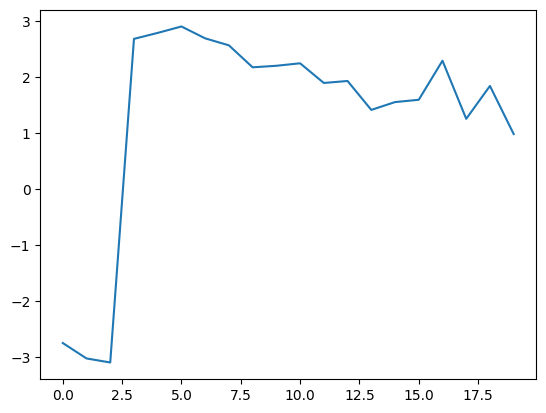

In [117]:
plt.plot(data_matrix[3,:,0])

done tt=0, time = 0.002
done tt=1, time = 0.002
done tt=2, time = 0.001
done tt=3, time = 0.002
done tt=4, time = 0.002
done tt=5, time = 0.002
done tt=6, time = 0.005
done tt=7, time = 0.003
done tt=8, time = 0.002
done tt=9, time = 0.002
done tt=10, time = 0.002
done tt=11, time = 0.002
done tt=12, time = 0.002
done tt=13, time = 0.002
done tt=14, time = 0.002
done tt=15, time = 0.001
done tt=16, time = 0.001
done tt=17, time = 0.001
done tt=18, time = 0.001
done tt=19, time = 0.002
done tt=20, time = 0.001
done tt=21, time = 0.001
done tt=22, time = 0.001
done tt=23, time = 0.002
done tt=24, time = 0.002
done tt=25, time = 0.002
done tt=26, time = 0.002
done tt=27, time = 0.002
done tt=28, time = 0.002
done tt=29, time = 0.003
done tt=30, time = 0.001
done tt=31, time = 0.002
done tt=32, time = 0.002
done tt=33, time = 0.002
done tt=34, time = 0.002
done tt=35, time = 0.002
done tt=36, time = 0.001
done tt=37, time = 0.001
done tt=38, time = 0.001
done tt=39, time = 0.002
done tt=40

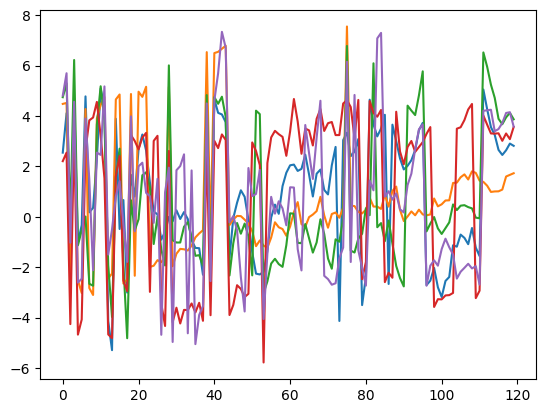

In [118]:
# array of fitted taus for each time, for each (non-reference) antenna
taus_fitted = np.zeros((ntimes,nant_used-1),dtype='float64')

# make some guess about fitted taus (for one sample time)
taus_guess_single = np.ones(nant_used-1)

for tt in range(ntimes):
    ydata = data_matrix[tt,:,:].ravel()
    if masking:
        weights = weight_matrix[tt,:,:]
    else:
        weights = weight_matrix[tt,:]
    t1=time.time()
    tau_fit_params = least_squares(func, taus_guess_single, args=(ydata, freqs_normalized, weights),
                                                        jac=jac,
                                                        method='lm',
                                                        ftol=1e-06, 
                                                        xtol=1e-06, 
                                                        gtol=1e-06, 
                                                        loss='linear')
    t2=time.time()
    taus_fitted[tt,:] = tau_fit_params['x']
    #print(fit_params)
    print(f"done tt={tt}, time = {t2-t1:5.3f}")
    
plt.plot(taus_fitted)

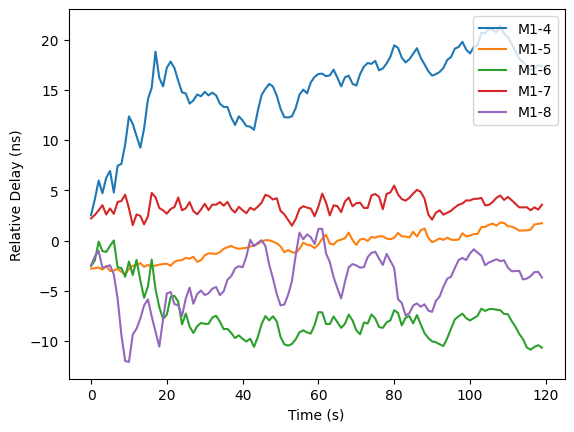

In [119]:
# unwrap the fitted taus into actual delay values
labels=['M1-4', 'M1-5', 'M1-6', 'M1-7', 'M1-8']
taus_unwrapped = np.unwrap(np.angle(np.exp(1j*taus_fitted.reshape(-1,nant_used-1)*2*np.pi*freqs_normalized.mean())),axis=0)/(2*np.pi*freqs_normalized.mean())

# plot the relative delays of the other antenna with respect to the reference antenna
plt.plot(taus_unwrapped[:,:],label=labels)
plt.ylabel('Relative Delay (ns)')
plt.xlabel('Time (s)')
plt.legend(loc='upper right')

15


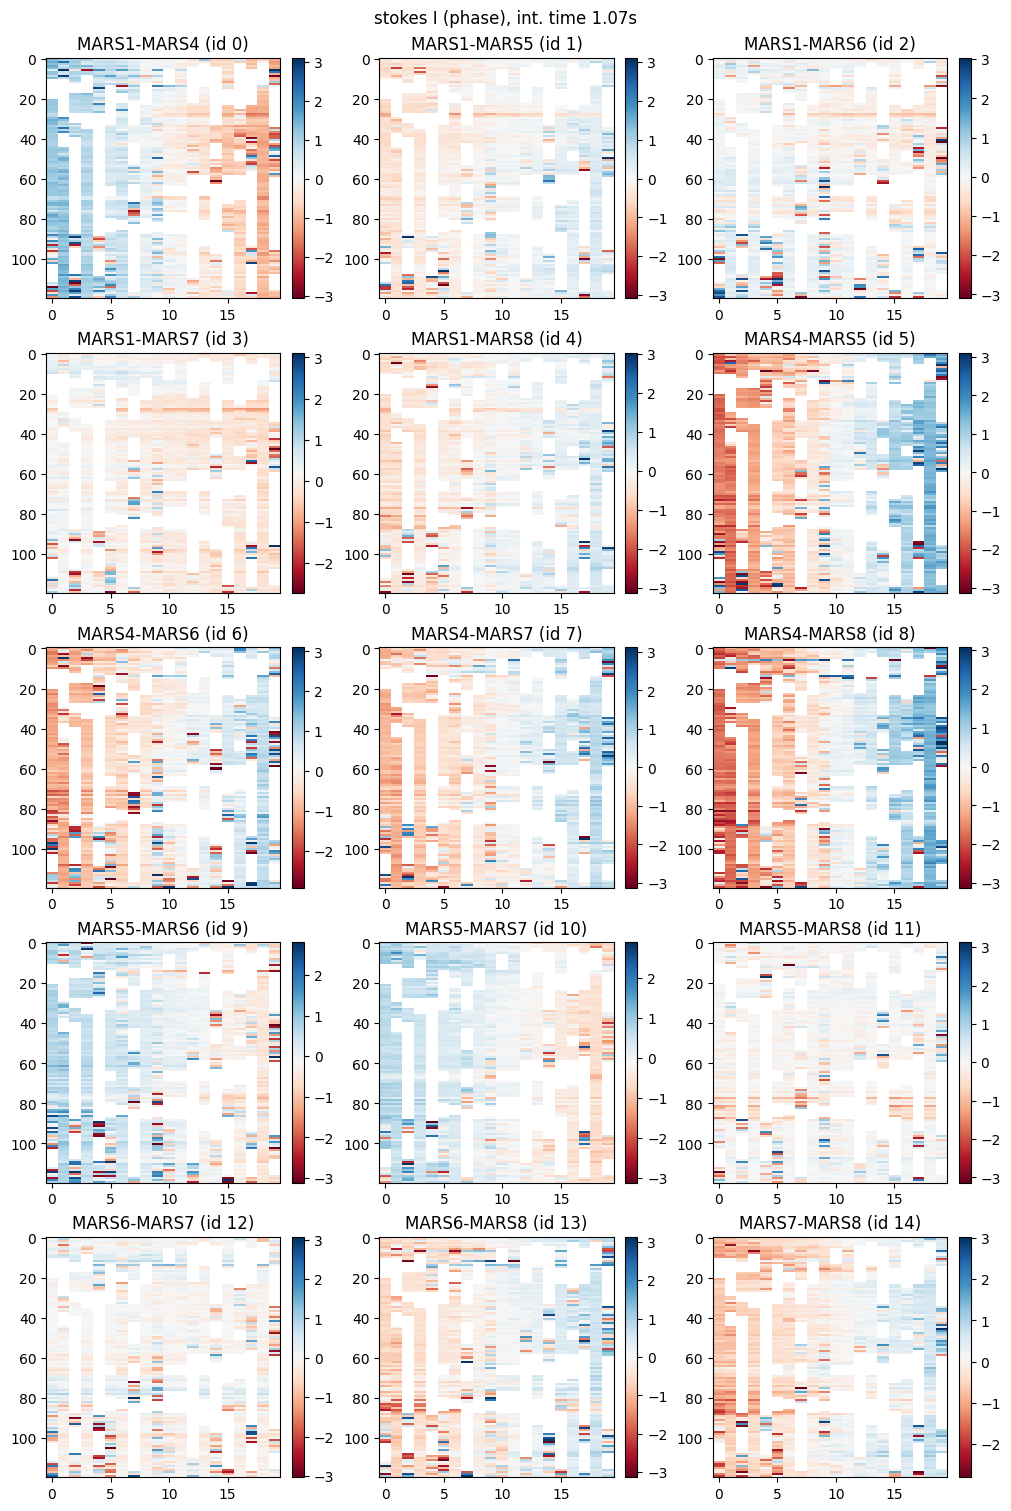

In [120]:
#generate aligned phase plots for each baseline with fitted taus
#in the meantime also phases the visibilities to align them

antmap = {0:"MARS1", 1:"MARS2",2:"MARS4",3:"MARS5",4:"MARS6",5:"MARS7",6:"MARS8"}
fig,ax = plt.subplots(5,3, constrained_layout=True)
fig.set_size_inches(10,15)
ax=np.ravel(ax)

blnum=0
print(n_blines)
plt.suptitle(f"stokes I (phase), int. time {T_SPECTRA*acclen:4.2f}s")
x = np.arange(nchans)
phased_vis = np.empty_like(vis2[:,:,:])
for i in range(len(ant_idxs)):
        for j in range(i+1, len(ant_idxs)):
            ai = ant_idxs[i]
            aj = ant_idxs[j]
            if i==0:
                tau1=0
            else:
                tau1 = taus_unwrapped[:,i-1]
            tau2 = taus_unwrapped[:,j-1]
            rel_delay = tau1-tau2
            ax[blnum].set_title(f"{antmap[ai]}-{antmap[aj]} (id {blnum})")
            phased_vis[blnum,:,:] = vis2[blnum,:,:]*np.exp(-2j*np.pi*freqs_normalized[None,:]*rel_delay[:,None])
            if masking:
                phased_vis_masked = np.ma.masked_where(mask2, np.angle(phased_vis[blnum,:,:]))
                img = ax[blnum].imshow(phased_vis_masked, aspect='auto', interpolation='none', cmap='RdBu')
                cbar=plt.colorbar(img,ax=ax[blnum])
            else:
                img=ax[blnum].imshow(np.angle(phased_vis[blnum,:,:]),aspect='auto',interpolation='none',cmap='RdBu')
                cbar=plt.colorbar(img,ax=ax[blnum])
            blnum+=1
# plt.tight_layout()

(20, 15)
[[0.0993903  0.03314336 0.06672774 0.06327648 0.03246639 0.06875671
  0.04471809 0.10016412 0.07487879 0.03834281 0.05134222 0.03435558
  0.07218551 0.05604182 0.05424973]]


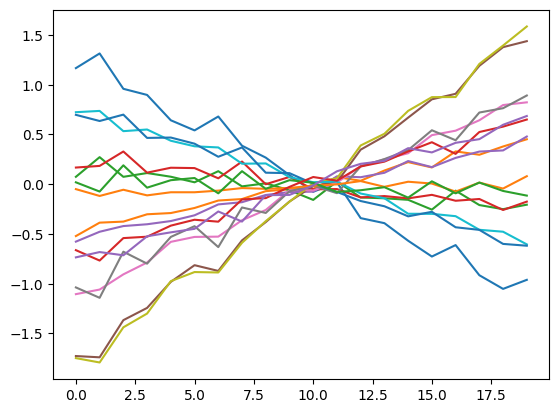

In [121]:
#phased vis is now the array of interest

#take average across time once aligned to boost SNR
if masking:
    #introduce mask 3 or something to check if there are enough points ALONG TIME. 
    #if bad, just interpolate after the fact and assign high noise value
    phased_vis_masked = np.ma.array(phased_vis, mask=np.broadcast_to(mask2[None, :, :], phased_vis.shape))
    avg_multi_vis = phased_vis_masked.mean(axis=1)
else:
    avg_multi_vis = np.mean(phased_vis, axis=1)


#avg_multi_vis = np.mean(phased_vis,axis=1)
# avg_multi_vis = np.median(phased_vis,axis=1)

#now have very clean phase ramp with super low noise
avg_multi_vis = avg_multi_vis.T.copy()
plt.plot(np.unwrap(np.angle(avg_multi_vis),axis=0))
print(avg_multi_vis.shape)


#get that noise by fitting a line and getting std of residuals
noise_matrix_avg = np.zeros((1,n_blines),dtype='float64')
for bl in range(n_blines):
    y = np.unwrap(np.angle(avg_multi_vis[:,bl]))
    m, c = np.polyfit(x,y, 1)
    residual = y - (m*x + c)
    noise_matrix_avg[0,bl] = np.std(residual)
print(noise_matrix_avg)

In [122]:
ntime2=1
nant=6
nbl=nant*(nant-1)//2

#can now just fit linearly using normal equations
data_matrix = np.unwrap(np.angle(avg_multi_vis),axis=0)
data_matrix = data_matrix.reshape(ntime2,nchans,nblines)

Ag = hf.get_grammian(nant)
print(data_matrix.shape)

AtA2,Atd2 = hf.get_AtA_Atd(data_matrix,
                            Ag,
                            noise_matrix_avg**2,
                            freqs_normalized,
                            nant,
                            nchans,
                            ntime2,
                            fit_constant=True)

AtA_inv2 = np.linalg.inv(AtA2)

mfit2 = AtA_inv2 @ Atd2
print(mfit2)
# Total parameters for tau: ntime * (nant-1)
bs = nant - 1
tau_linear2 = mfit2[:ntime2 * bs]
phi_linear2 = mfit2[ntime2 * bs:]
errs_all = np.sqrt(np.diag(AtA_inv2))
print(tau_linear2)
print('test')

taus_fitted_all = tau_linear2[:, np.newaxis] + taus_unwrapped.T
taus_errs_all = errs_all[:nant-1]
print(errs_all)

(1, 20, 15)
Snu 17.293775828550274 Snu2 14.953734144284585
[-20849.64651857   7810.66296789  -3595.16174913  -4278.92705101
   8671.05243446  18028.36055724  -6753.75346055   3108.69306457
   3699.93666699  -7497.70582872]
[-20849.64651857   7810.66296789  -3595.16174913  -4278.92705101
   8671.05243446]
test
[236.6877559  153.83032637 193.77179585 211.60375828 155.40302745
 204.66124976 133.0153591  167.5523001  182.97139815 134.37525609]


In [21]:
# with h5py.File('finetiming_dump1.h5', 'a') as f:
#     ds = f.create_dataset(fname_data, data=taus_fitted_all)
#     ds.attrs['starting_specnum'] = pulse_start_spec_cut